## Функция проверки нормальности распределения случайной величины с помощью критерия хи-квадрат Пирсона

*Так как в доступных инструментах Python не представлена готовая реализация χ²-критерия согласия с нормальным распределением, перед автором этой работы встала задача написать её самостоятельно. Ниже приведены реализация теста и проверка его работы*

Метод χ² основан на разбиении выборки на интервалы и сравнении наблюдаемых частот попадания значений в эти интервалы с ожидаемыми частотами, рассчитанными при предположении нормальности распределения. Критерий был предложен К. Пирсоном в 1900 году и в настоящее время чаще применяется для анализа категориальных данных, то есть данных, изначально представленных в виде дискретных групп (интервалов). Тем не менее, приведённая ниже функция адаптирует данный подход для работы с числовыми (непрерывными) данными. В дальнейшем эта реализация используется в общей процедуре проверки нормальности распределения случайной величины, основанной на применении пяти распространённых критериев, включая критерий согласия Пирсона (χ²)

### χ² тест на нормальность. Алгоритм

Формулировка гипотез:
- H[0] (нулевая гипотеза): Данные распределены нормально
- H[1] (альтернативная гипотеза): Данные не распределены нормально

Подготовка данных:
- Рассчитать выборочное среднее и стандартное отклонение
- Вычислить число интервалов по правилу Стёрджеса 
$$
k = 1 + 3{,}322 \,\lg N
$$
 округлённое до целого в большую сторону. Обычно используют от 5 до 20 бинов
- Разбить диапазон данных на \(k\) интервалов
- Частота попадания в каждый интервал должна быть не меньше 5, в противном случае нужно склеить интервалы

Непосредственно тест:
- Рассчитать хи-квадрат статистику (встроенная функция scipy.stats)
- Рассчитать число степеней свободы как количество интервалов - 1 - число параметров распределения (их 2: среднее и стандартное отклонение)
- С помощью статистики и числа степеней свободы рассчитываем p-value

Вывод
- Если p-value больше уровня значимости alpha, значит нет оснований отвергать нулевую гипотезу о нормальности распределения
- В противном случае отвергаем нулевую гипотезу

In [2]:
# импорт библиотек
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.stats.diagnostic import lilliefors
sns.set_style('darkgrid')

### Реализация функции χ² теста

In [3]:
def chi2_norm_test(X, n_bins='auto', alpha=0.05):
    X = np.array(X)
    n = len(X)
    
    # Рассчитываем среднее и стандартное отклонение по выборке
    mean = np.mean(X)
    std = np.std(X, ddof=1)

    if n_bins == 'auto':
        # Определяем количество интервалов (Правило Стёрджеса)
        n_bins = int(np.ceil(1 + 3.322 * np.log10(n)))
        # Ограничиваем количество интервалов от 5 до 20
        n_bins = max(5, min(n_bins, 20))

    # Вычисляем наблюдаемые частоты и границы бинов (с помощью np.histogram - возвращает кортеж с частотами попадания в каждый бин и кортеж с границами бинов) 
    observed_freq, bin_edges = np.histogram(X, bins=n_bins) 


     # Вычисляем ожидаемые частоты для нормального распределения
    expected_freq = []

    # критерий хи2 требует равенства сумм частот двух сравниваемых распределений ∑Oi ​= ∑Ei = n. Нормальное распределений имеет бесконечные хвосты справа и слева,
    # поэтому первый бин нужно начинать с −∞, а последний заканчивать +∞
    for i in range(len(bin_edges) - 1):
        # У первого бина левая граница −∞, поэтому берём просто cdf на правой границе
        if i == 0:
            prob = stats.norm.cdf(bin_edges[1], mean, std)
        # У последнего бина правая граница +∞, поэтому 1 - cdf на левой границе
        elif i == len(bin_edges) - 2:
            prob = 1 - stats.norm.cdf(bin_edges[-2], mean, std)
        # У остальных бинов считаем ожидаемое значение как разность высот функции нормального распределения в конце и в начале интервала т. е. вероятность попадания в него
        else:
            prob = (stats.norm.cdf(bin_edges[i+1], mean, std) - stats.norm.cdf(bin_edges[i], mean, std))
        # Умножаем вероятности попадания в бин на n - вычисляем ожидаемые частоты
        expected_freq.append(prob * n)
    
    expected_freq = np.array(expected_freq)
    observed_freq = np.array(observed_freq)

    # Объединяем интервалы с маленькими ожидаемыми частотами чтобы все ожидаемые частоты были >= 5
    min_expected = 5
    observed_merged = []
    expected_merged = []
    
    temp_obs = 0
    temp_exp = 0
    
    for i in range(len(observed_freq)):
        temp_obs += observed_freq[i]
        temp_exp += expected_freq[i]
        
        # Если накопленная ожидаемая частота >= 5 - сохраняем в результат.
        # Тут проверяются именно ожидаемые частоты, потому, что тест хи2 использует формулу χ² = Σ [(Oᵢ - Eᵢ)² / Eᵢ] 
        # и если знаменатель будет слишком мал, может не получиться хи2 распределения статистики
        if temp_exp > min_expected and i != len(observed_freq) - 1:
            observed_merged.append(temp_obs)
            expected_merged.append(temp_exp)
            temp_obs = 0
            temp_exp = 0
        # Границы интервалов не меняем, т к они не используются в тесте

        # Последний проверим отдельно
        elif i == len(observed_freq) - 1:
            if temp_exp >= min_expected:
                # Если накопленная частота >= 5, сохраняем
                observed_merged.append(temp_obs)
                expected_merged.append(temp_exp)
            else:
                # Если < 5, объединяем с предыдущим интервалом
                # try-except для обработки случаев с очень маленькой выборкой, чтобы в следующей функции не возникало ошибок
                try:
                    observed_merged[-1] += temp_obs
                    expected_merged[-1] += temp_exp
                except IndexError:
                    # Список пустой - просто добавляем
                    observed_merged.append(temp_obs)
                    expected_merged.append(temp_exp)

    observed_merged = np.array(observed_merged)
    expected_merged = np.array(expected_merged)
    
    # Вычисляем статистику хи-квадрат
    chi2_stat, _ = stats.chisquare(observed_merged, expected_merged)
    
    # Степени свободы: k - 1 - p
    # k = количество интервалов
    # p = количество оцениваемых параметров (для нормального: 2 - mean и std)
    dof = len(observed_merged) - 1 - 2
    
    # Обрабатываем случай когда число степеней свободы <= 0
    if dof <= 0:
        return {
        'Статистика': np.nan,
        'P-value': np.nan,
        'Ошибка': 'Недостаточно степеней свободы'
    }

    # Считаем p-value со степенями свободы как P(χ2 >= χ2набл​) - правый "хвост" распределения
    p_value = stats.chi2.sf(chi2_stat, dof)
    
    return {
        'Статистика': round(chi2_stat, 2),
        'P-value': round(p_value, 5),
        'Степени свободы': dof,
        'Число интервалов': len(observed_merged),
        'Мин. ожидаемая частота': round(np.min(expected_merged), 5),
        'Нормальность': 'Да' if p_value > alpha else 'Нет'
    }

### Тестирование функции χ² теста

Цель тестирования — оценить корректность работы реализованной функции χ²-критерия согласия при проверке гипотезы о нормальности распределения.  

Ожидаемые результаты:  
1. Для нормально распределённых данных критерий должен редко отвергать нулевую гипотезу H[0] о нормальности **(ошибка I рода)**
2. Для данных с ненормальным распределением критерий должен часто отвергать H[0]​, демонстрируя высокую мощность теста **(низкая вероятность ошибки II рода)**

>Проверка корректности уровня значимости (ошибки I рода)
>Для этого генерируются по 5000 выборок различных объёмов (50, 100, 500, 1000, 5000 и 10000), полученных из нормального распределения. Для каждой выборки вычисляется p-value критерия. При корректной работе теста распределение p-value должно быть близким к равномерному на интервале [0,1], а доля отклонений нулевой гипотезы — близкой к заданному уровню значимости α=0.05.

>Оценка мощности критерия
>Далее проводится аналогичный имитационный эксперимент методом Монте-Карло для выборок из различных ненормальных распределений. В этом случае оценивается доля отклонений нулевой гипотезы, которая интерпретируется как эмпирическая мощность критерия.

#### Проверим нормальные входные данные (ошибку I рода)

In [ ]:
sizes = [50, 100, 500, 1000, 5000, 10000]
alpha = 0.05
results = []
rng = np.random.default_rng(42) # фиксированный генератор случайных чисел гарантирует одинаковый результат при многократном выполнении этой ячейки

for n in sizes:
    p_values = []
    for _ in range(5000):
        X = rng.normal(loc=0, scale=1, size=n)
        res = chi2_norm_test(X)
        p_values.append(res['P-value'])

    # Доля ложных ответов (ложных отклонений H[0])
    rejection_rate = np.mean(np.array(p_values) < alpha)

    # записываем в результат
    results.append({
        'Sample size': n,
        'Rejection rate': rejection_rate
    })

df_results = pd.DataFrame(results)

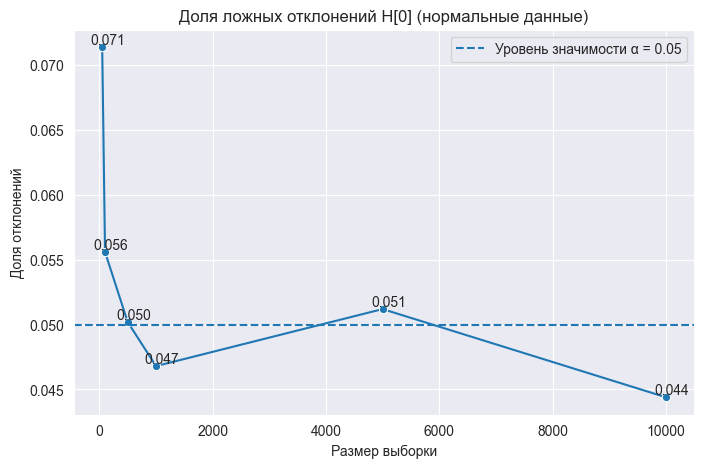

In [ ]:
# График доли ложных ответов
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_results, x='Sample size', y='Rejection rate', marker='o')

plt.axhline(alpha, linestyle='--', label='Уровень значимости α = 0.05')
plt.title('Доля ложных отклонений H[0] (нормальные данные)')
plt.ylabel('Доля отклонений')
plt.xlabel('Размер выборки')
plt.legend()
plt.grid(True)

for x, y in zip(df_results['Sample size'], df_results['Rejection rate']):
    plt.text(x + 100, y + 0.00001, f"{y:.3f}", ha='center', va='bottom')

plt.show()

>Функция демонстрирует корректный уровень значимости при нормальных данных   
>(частота ложных отклонений близка к 0.05). При малых выборках чувствительность теста более низкая

#### Проверим ненормальные входные данные (мощность теста)


In [ ]:
sizes = [50, 100, 500, 1000, 5000, 10000] # размер выборки
alpha = 0.05
n_simulations = 3000 # число симуляций; уменьшаем для скорости
rng = np.random.default_rng(42)

# Словарь ненормальных распределений
distributions = {
    'Экспоненциальное': lambda n: rng.exponential(scale=1, size=n), # Сильно ассиметричное
    'Равномерное': lambda n: rng.uniform(low=-np.sqrt(3), high=np.sqrt(3), size=n),
    'Стьюдента': lambda n: rng.standard_t(df=3, size=n), # Распределение Стьюдента с тремя степенями свободы, колоколообразное, но с тяжёлыми хвостами
    'Гамма': lambda n: rng.gamma(shape=2, scale=1, size=n), # Гамма-распределение, скошенное вправо
    'Биномиальное': lambda n: rng.binomial(n=100, p=0.5, size=n) # Маленькие выборки выглядят ненормальными, но на больших n (первый параметр) распределение становится почти нормальным
}

results = []
for name, func in distributions.items():
    for n in sizes:
        p_values = []
        for _ in range(n_simulations): 
            X = func(n)
            res = chi2_norm_test(X)
            p_values.append(res['P-value'])
        
        p_values = np.array(p_values)
        power = np.mean(p_values < alpha)
        results.append({
            'Distribution': name,
            'Sample size': n,
            'Power': power
        })

df_power = pd.DataFrame(results)

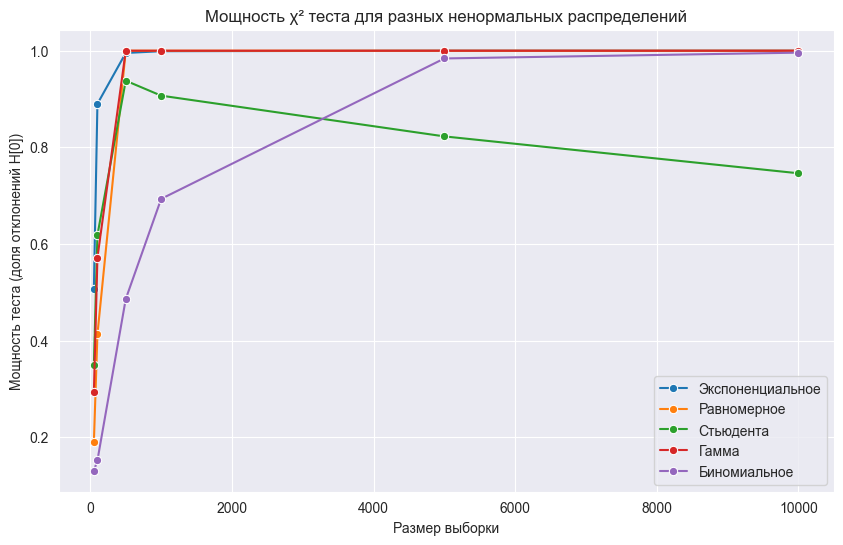

In [ ]:
# График мощностей теста при разных размерах и распределениях входных данных
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_power, x='Sample size', y='Power', hue='Distribution', marker='o')

plt.title('Мощность χ² теста для разных ненормальных распределений')
plt.ylabel('Мощность теста (доля отклонений H[0])')
plt.xlabel('Размер выборки')
plt.grid(True)
plt.legend()
plt.show()

**Комментарий к графику**  
🔵 Экспоненциальное: мощность почти сразу поднимается близко к 1, благодаря сильной асимметрии  
🟠 Равномерное: мощность также быстро достигает значений около 1, так как форма распределения сильно отличается от колоколообразной  
🔴 Гамма: есть асимметрия и более тяжёлый правый хвост по сравнению с нормальным. С ростом n тест точнее видит эти отличия   
🟢 Стьюдента: мощность сначала высокая, а потом падает при росте выборки. Это симметричное распределение, его центр похож на нормальный, отличия только в тяжёлых хвостах. При большом размере эти хвосты распределяются по нескольким бинам и разница уже не такая заметная, поэтому тест становится менее чувствительным  
🟣 Биномиальное (n=100, p=0.5): при n=100 распределение похоже на нормальное, тем не менее оно дискретное и имеет ограниченный диапазон в отличии от нормального. С увеличением выборки мощность монотонно растёт к 1  

**Резюме**  
 Мощность теста возрастает с увеличением объема выборки и особенно высока для асимметричных распределений. Функция проверки нормальности распределения с помощью критерия согласия Пирсона (χ²) работает корректно.


## Функция проверки нормальности распределения случайной величины с помощью нескольких популярных критериев

<span style="font-size: 16px">Ниже представлена пользовательская функция проверки распределения случайной величины на нормальность несколькими популярными методами, а именно тест Шапиро-Уилка, тест Колмогорова-Смирнова с поправкой Лиллиефорса, тест Д'Агостино-Пирсона, критерий Хи-квадрат и критерий Андерсона—Дарлинга.</span>

**1. Тест Шапиро-Уилка**
- Оптимален для малых и средних выборок (n = 3–5000)
- Чаще всего применяется на небольших выборках < 50
- Для очень больших выборок может быть слишком чувствителен

**2. Тест Колмогорова-Смирнова с поправкой Лиллиефорса**  
*далее критерий Лиллиефорса*
- Считается более подходящим для больших выборок
- В отличие от теста Шапиро-Уилка, критерий Колмогорова-Смирнова более чувствителен к различиям в форме распределения при больших выборках
- Поправка Лиллиефорса делает тест менее консервативным

**3. тест Д'Агостино-Пирсона**
- Основан на анализе асимметрии и эксцесса выборки
- Подходит для средних (от 20-50 до нескольких сотен) выборок

**4. Хи-квадрат (критерий согласия Пирсона)**
- Разбивает данные на интервалы и считает статистику исходя из частот попадания в эти интервалы
- Следует использовать на выборках > 100 
- Удобно применять, когда данные уже разбиты на категории. Но функция, приведённая здесь предназначена для числовых данных и разбивает их на интервалы искусственно
- Подходит для случаев, когда остальные тесты на больших выборках становятся слишком чувствительными к малейшим отклонениям от нормальной кривой

**5. критерий Андерсона—Дарлинга**
- модификация критерия Колмогорова-Смирнова с более высокой чувствительностью к выбросам, отклонениям в "хвостах" распределения
- Желательно использовать на выборках размером  от 8 до 500

### Реализация функции 

In [4]:
''' 
Функция принимает на вход случайную величину X и уровень значимость alpha, по умолчанию 0,05
Возвращает датафрейм с результатами тестов 
'''
def norm_dist_check(X, alpha=0.05): 
    results = []
    n = len(X)
    # 1. Шапиро-Уилка
    # Работает для выборок от 3 до 5000 наблюдений. Наиболее эффективен для маленьких.
    if n > 5000:
        results.append({
            'Тест': 'Шапиро-Уилка',
            'Статистика': np.nan,
            'P-value': np.nan,
            'Критическое значение': np.nan,
            'Нормальность': 'Выборка > 5000'
        })
    else:
        stat, p = stats.shapiro(X)
        results.append({
            'Тест': 'Шапиро-Уилка',
            'Статистика': stat,
            'P-value': p,
            'Критическое значение': np.nan,
            'Нормальность': 'Да' if p > alpha else 'Нет'
        })
    
    # 2. Колмогорова-Смирнова с поправкой Лиллиефорса (для n >= 50)
    if n < 50:
        results.append({
            'Тест': 'Лиллиефорса',
            'Статистика': np.nan,
            'P-value': np.nan,
            'Критическое значение': np.nan,
            'Нормальность': 'Выборка < 50'
        })
    else:
        stat, p = lilliefors(X, 'norm')
        results.append({
            'Тест': 'Лиллиефорса',
            'Статистика': stat,
            'P-value': p,
            'Критическое значение': np.nan,
            'Нормальность': 'Да' if p > alpha else 'Нет'
        })
    
     # 3. Д'Агостино-Пирсона (normaltest) (n >= 20)
    if n < 20:
        results.append({
            'Тест': "Д'Агостино-Пирсона",
            'Статистика': np.nan,
            'P-value': np.nan,
            'Критическое значение': np.nan,
            'Нормальность': 'Выборка < 20'
        })
    else:
        stat, p = stats.normaltest(X, axis=0)
        results.append({
            'Тест': "Д'Агостино-Пирсона",
            'Статистика': stat,
            'P-value': p,
            'Критическое значение': np.nan,
            'Нормальность': 'Да' if p > alpha else 'Нет'
        })

    # 4. Хи-квадрат (Для больших выборок)
    if n < 100:
        results.append({
            'Тест': 'Хи-квадрат',
            'Статистика': np.nan,
            'P-value': np.nan,
            'Критическое значение': np.nan,
            'Нормальность': 'Выборка < 100'
        })
    else:
        chi2_result = chi2_norm_test(X, alpha=alpha)
        results.append({
        'Тест': 'Хи-квадрат',
        'Статистика': chi2_result['Статистика'],
        'P-value': chi2_result['P-value'],
        'Критическое значение': np.nan,
        'Нормальность': 'Да' if chi2_result['P-value'] > alpha else 'Нет'
            })

    # 5. Андерсона-Дарлинга  
    if n < 8:
        results.append({
            'Тест': 'Андерсона-Дарлинга',
            'Статистика': np.nan,
            'P-value': np.nan,
            'Критическое значение': np.nan,
            'Нормальность': 'Выборка < 8'
        })
    else:
        ad_result = stats.anderson(X, dist='norm')

        # В большинстве версий scipy функция stats.anderson() не возвращает p_value. Проверим, есть оно ими нет, чтобы избежать ошибок
        if hasattr(ad_result, 'pvalue') and ad_result.pvalue is not None: 
            ad_crit = ad_result.pvalue
            ad_normal = 'Да' if ad_p > alpha else 'Нет'
        else:
            # У этого теста в python уровни значимости только [0.15, 0.1, 0.05, 0.025, 0.01]
            # Если переданный в функцию alpha не соответствует ни одному из этих значений, используем для расчёта p_value ближайший более строгий уровень значимости
            levels = list(ad_result.significance_level / 100)
            if alpha in levels:
                crit_idx = levels.index(alpha)
            else:
                possible = levels[levels <= alpha]
                if len(possible) == 0:
                    crit_idx = len(levels) - 1  # самый строгий (1%)
                else:
                    crit_idx = levels.index(max(possible))

            # В данном тесте обычно не вычисляют p_value, вместо этого сравнивают заранее известное критическое значение со статистикой
            ad_crit = ad_result.critical_values[crit_idx]
            ad_normal = 'Да' if ad_result.statistic < ad_result.critical_values[crit_idx] else 'Нет'
        
        results.append({
            'Тест': 'Андерсона-Дарлинга',
            'Статистика': ad_result.statistic,
            'P-value': np.nan,
            'Критическое значение': ad_crit,
            'Нормальность': ad_normal
        })

    df_results = pd.DataFrame(results)
    
    # во время тестирования эти 3 строки нужно закомментировать
    print(f'\nРазмер выборки: n = {n}') 
    print(f'Уровень значимости: α = {alpha}')
    print('-' * 85)
    
    return df_results

### Тестирование функции проверки нормальности распределения

Для оценки корректности работы реализованной функции, объединяющей несколько критериев проверки нормальности, проводится имитационное тестирование, направленное на анализ ошибок I и II рода.  

Структура тестирования
1. Ошибка I рода (α): тест отвергает H[0] (нормальность), когда данные нормальные
2. Ошибка II рода (β): тест не отвергает H[0], когда данные ненормальные, мощность теста: 1 - β (способность обнаружить отклонение)  

Оценка ошибки I рода
> Для оценки фактического уровня значимости генерируются по 3000 выборок различных объёмов [30, 50, 100, 200, 500, 1000, 2000], полученных из нормального распределения. Каждая выборка проверяется на нормальность с использованием реализованной функции. Для каждого критерия рассчитывается доля отклонений нулевой гипотезы, которая интерпретируется как эмпирическая вероятность ошибки I рода. Результаты визуализируются на графике в виде зависимости этой величины от объёма выборки для каждого теста.

Оценка мощности критериев
>Для оценки мощности тестов проводится аналогичный имитационный эксперимент методом Монте-Карло с использованием выборок из различных ненормальных распределений. Рассматриваются те же объёмы выборок и то же число симуляций (3000). Для каждого распределения и каждого критерия вычисляется доля отклонений нулевой гипотезы, которая интерпретируется как эмпирическая мощность теста. Результаты представляются в виде тепловых карт, позволяющих наглядно сравнить чувствительность различных критериев к отклонениям от нормальности.

#### Оценка ошибки I рода

In [7]:
n_simulations=3000
sample_sizes=[30, 50, 100, 200, 500, 1000, 2000]
alpha=0.05
rng = np.random.default_rng(42)

# Словарь списков для подсчёта ложных отклонений нулевой гипотезы
results = {test: [] for test in ['Шапиро-Уилка', 'Лиллиефорса', "Д'Агостино-Пирсона", 'Хи-квадрат', 'Андерсона-Дарлинга']} # Создаёт словарь {название теста: пустой список}

for n in sample_sizes:
        rejections = {test: 0 for test in results.keys()} # Создаёт словарь {название теста: 0} сдаю будет записываться количество ошибок
        
        for _ in range(n_simulations):
            # Генерируем нормальные данные
            X = rng.normal(0, 1, n)
            df_res = norm_dist_check(X, alpha=alpha)
            
            # Подсчитываем отвержения H0. Если встречается "нет" - записываем +1 в отклонения
            for _, row in df_res.iterrows():
                if row['Нормальность'] == 'Нет':
                    rejections[row['Тест']] += 1

                # Вычисляем долю ложных отвержений
        for test in results.keys():
            results[test].append(rejections[test] / n_simulations)
    
results = pd.DataFrame(results, index=sample_sizes)

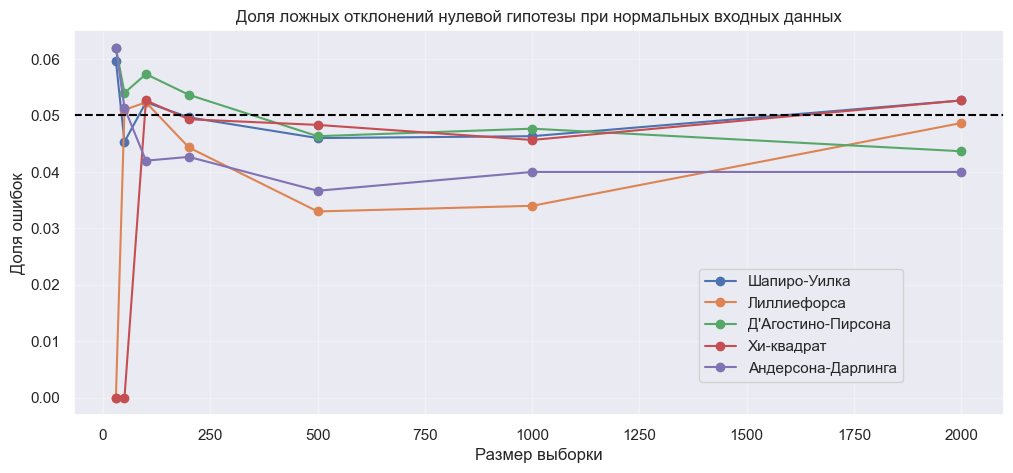

In [11]:
# График 
plt.figure(figsize=(12, 5))
sns.set_theme(style='darkgrid')

for col in results.columns:
    plt.plot(results.index, results[col], marker='o', label=col)

plt.legend(bbox_to_anchor=(0.9, 0.4))
plt.axhline(y=0.05, color='black', linestyle='--', label='α = 0.05')
plt.title('Доля ложных отклонений нулевой гипотезы при нормальных входных данных')
plt.ylabel('Доля ошибок')
plt.xlabel('Размер выборки')
plt.grid(True, alpha=0.3)
plt.show()

>График показывает, что большинство тестов держат заявленный уровень ошибки I рода 5%, при этом критерий Лиллиефорса и тест Андерсона-Дарлинга оказались более консервативными в этой реализации

#### Оценка ошибки II рода

В рамках оценки ошибки II рода и мощности критериев используются выборки из ряда ненормальных распределений, обладающих различными типами отклонений от нормальности.

Параметры всех распределений, за исключением логнормального, выбраны таким образом, чтобы их математическое ожидание равнялось нулю, а дисперсия — единице, что соответствует параметрам стандартного нормального распределения. Такая стандартизация обеспечивает сопоставимость распределений по масштабу и положению на числовой оси, позволяя оценивать чувствительность тестов именно к форме распределения, а не к различиям в среднем или дисперсии.

Используются следующие распределения:
1. Экспоненциальное распределение — характеризуется выраженной правосторонней асимметрией и длинным правым хвостом.
2. Распределение Стьюдента с тремя степенями свободы — симметричное распределение с тяжёлыми хвостами.
3. Хи-квадрат распределение с двумя степенями свободы — асимметричное распределение с выраженным правым хвостом.
4. Логнормальное распределение с параметрами μ=0, σ=0,5 — положительно скошенное распределение с асимметрией и утяжелённым правым хвостом.
5. Смесь двух нормальных распределений — бимодальное распределение.

In [5]:
rng = np.random.default_rng(42)

# Создадим функции для распределений, будет более читаемо, чем множество анонимных функций подряд
def exp_dist(n):
    x = rng.exponential(scale=1, size=n) # первый параметр - λ. Дисперсия = 1/λ^2
    return x - 1  # центрирование

def t3_dist(n):
    x = rng.standard_t(df=3, size=n) # Дисперсия = v / (v - 2) где v - число степеней свободы. Сейчас D(X) = 3
    return x / np.sqrt(3) # деление на корень из 3 чтобы дисперсия стала 1

def chi2_dist(n):
    x = rng.chisquare(df=2, size=n) # E(X) = v, D(X) = 2v где v - число степеней свободы. Сейчас E(X) = 2, D(X) = 4
    return (x - 2) / 2 # стандартизируем по формуле Z = (X - μ) / σ

def uniform_dist(n):
    # Для равномерного распределения D = (b - a)^2 / 12, если взять симметричное распределение с дисперсией 1, 
    # то единственно-возможные концы отрезка равны +- корень из 3
    return rng.uniform(-np.sqrt(3), np.sqrt(3), n) 


def lognorm_dist(n):
    x = rng.lognormal(mean=0, sigma=0.5, size=n) # параметры для умеренно асимметричного и скошенного вправо распределения. Если взять 0 и 1 - распределение будет сильно скошенным
    mean = np.exp(0.5**2 / 2) # Формулы для логнормального р. E(X) = exp((μ+σ^2)/2) примерно 1,13
    var = (np.exp(0.5**2) - 1) * np.exp(0.5**2) # D(X) = (exp(σ^2) − 1) * exp(2μ+σ^2) 
    # стандартизируем в соответствии с этими параметрами по общей формуле
    return (x - mean) / np.sqrt(var)

def mixture_dist(n):
    x = np.concatenate([ 
        rng.normal(-2, 1, n // 2), # первый компонент ~N(-2, 1), p=0.5
        rng.normal(2, 1, n - n // 2) # второй компонент ~N(-2, 1), p=0.5
    ])
    # Для смеси двух нормальных р. E(X) = 0.5 * (−2) + 0.5 * 2 = 0 (центр уже в нуле)
    # D(X) = E[D(X∣C)] + D(E[X∣C]) где C — номер компоненты, первое слагаемое - это средняя дисперсия внутри компонент, второе слагаемое - это дисперсия средних.
    # Среднее дисперсий = 1, так как у обеих компонент D(X) = 1
    # Формула для дисперсии средних: D(Y) = ∑ (​pi * ​(yi​ − E[Y])^2) Подставляем: D(E[X∣C]) = 0.5 * (−2−0)^2 + 0.5 * (2−0)^2 = 4
    # D(X) = 1 + 4 = 5 
    # Стандартизируем
    return x / np.sqrt(5)

# Словарь ненормальных распределений
distributions = {
    'Экспоненциальное': exp_dist,
    'Стьюдента': t3_dist,
    'Хи-квадрат': chi2_dist,
    'Равномерное': uniform_dist,
    'Логнормальное': lognorm_dist,
    'Смесь нормальных': mixture_dist
}


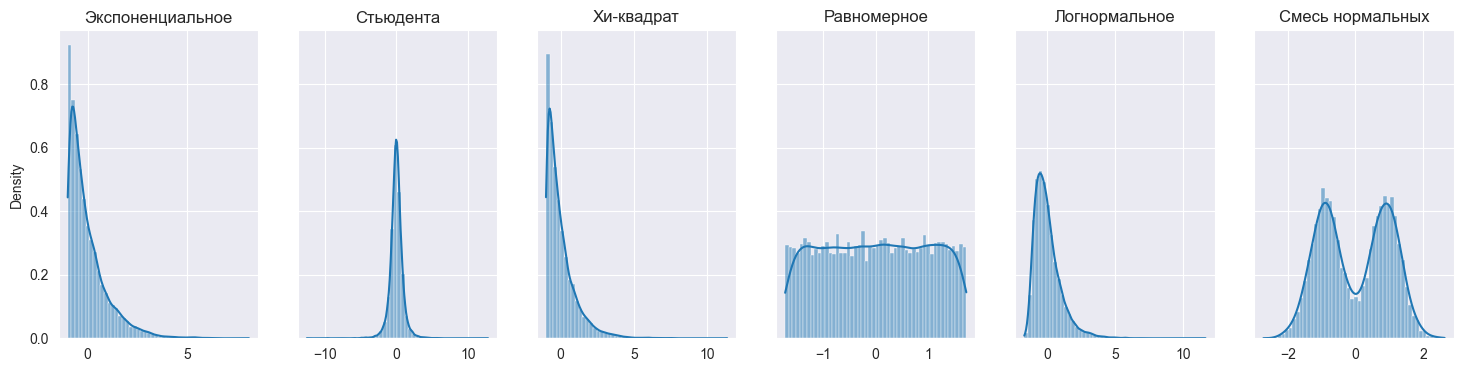

In [ ]:
# визуализация используемых в тесте ненормальных распределений
fig, axes = plt.subplots(1, 6, figsize=(18, 4), sharey=True)

sns.histplot(distributions['Экспоненциальное'](10000), bins=50, stat='density', kde=True, ax=axes[0])
axes[0].set_title('Экспоненциальное')

sns.histplot(distributions['Стьюдента'](10000), bins=50, stat='density', kde=True, ax=axes[1])
axes[1].set_title('Стьюдента')

sns.histplot(distributions['Хи-квадрат'](10000), bins=50, stat='density', kde=True, ax=axes[2])
axes[2].set_title('Хи-квадрат')

sns.histplot(distributions['Равномерное'](10000), bins=50, stat='density', kde=True, ax=axes[3])
axes[3].set_title('Равномерное')

sns.histplot(distributions['Логнормальное'](10000), bins=50, stat='density', kde=True, ax=axes[4])
axes[4].set_title('Логнормальное')

sns.histplot(distributions['Смесь нормальных'](10000), bins=50, stat='density', kde=True, ax=axes[5])
axes[5].set_title('Смесь нормальных')

plt.show()

In [ ]:
# Непосредственно тест на мощность (способность обнаружить отклонение от нормальности)
sizes = [30, 50, 100, 200, 500, 1000] # размеры выборки
alpha=0.05
n_simulations = 3000 # число симуляций
rng = np.random.default_rng(42) # фиксируем генератор случайных чисел

# Структура: {распределение: {тест: [мощности для разных n]}}
results = {dist: {test: [] for test in ['Шапиро-Уилка', 'Лиллиефорса', "Д'Агостино-Пирсона", 'Хи-квадрат', 'Андерсона-Дарлинга']} for dist in distributions.keys()}
    
for dist_name, dist_func in distributions.items(): # для каждого распределения 
    for n in sizes: # для каждого размера выборки
        rejections = {test: 0 for test in results[dist_name].keys()} # {тест: количество правильных ответов - отклонений H[0]}
        
        for _ in range(n_simulations):
            X = dist_func(n)
            df_res = norm_dist_check(X, alpha=alpha)
                
            for _, row in df_res.iterrows():
                test_name = row['Тест']
                if row['Нормальность'] == 'Нет':
                    rejections[test_name] += 1
            
        for test in results[dist_name].keys():
            results[dist_name][test].append(rejections[test] / n_simulations) # записываем количество отклонений H[0]

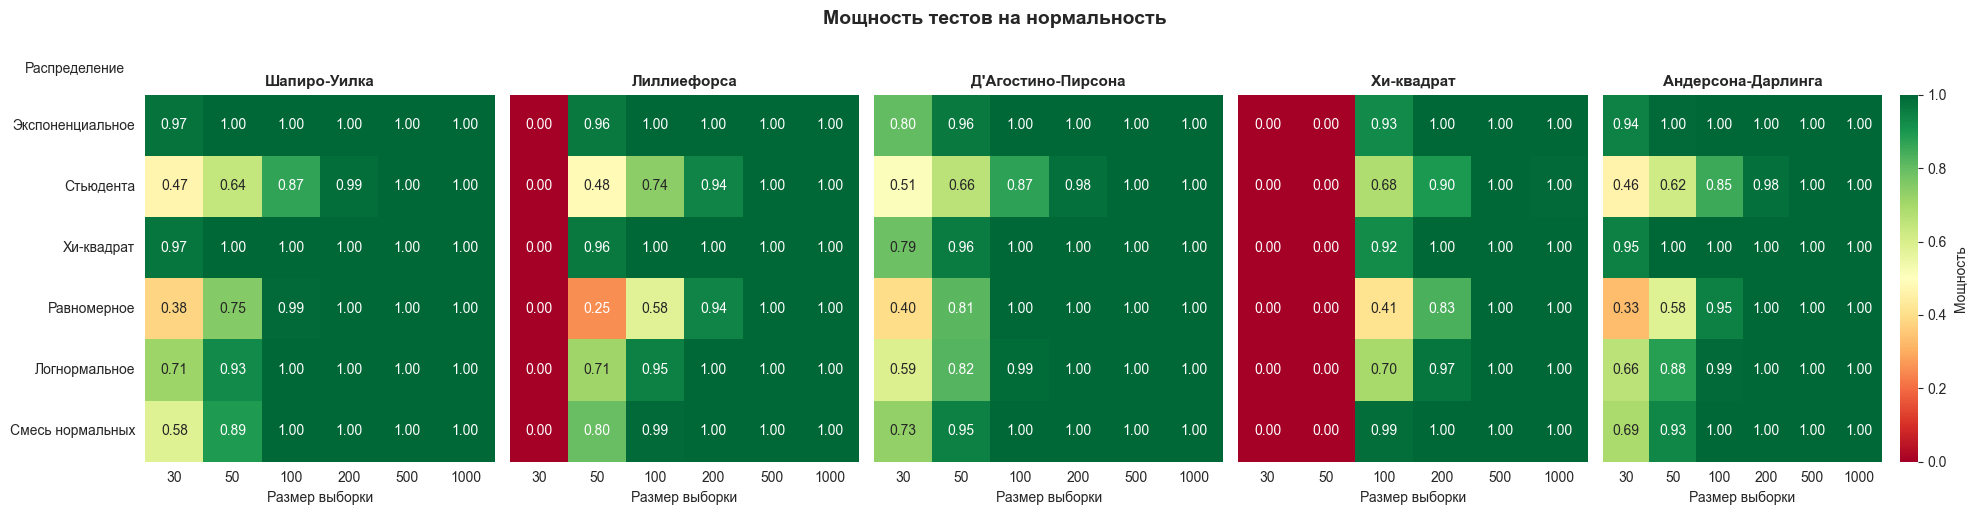

In [ ]:
# Визуализация результатов теста с помощью тепловых карт
tests = ['Шапиро-Уилка', 'Лиллиефорса', "Д'Агостино-Пирсона", 'Хи-квадрат', 'Андерсона-Дарлинга']
    
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    
for idx, test in enumerate(tests):
    # Создаём матрицу для heatmap
    data = []
    dist_names = []
    for dist_name, test_results in results.items():
        data.append(test_results[test])
        dist_names.append(dist_name)
        
    df_heat = pd.DataFrame(data, index=dist_names, columns=sizes)
        
    sns.heatmap(df_heat,
        annot=True, 
        fmt='.2f', 
        cmap='RdYlGn', 
        vmin=0, 
        vmax=1, 
        ax=axes[idx], 
        cbar=idx == len(tests) - 1, 
        cbar_kws={'label': 'Мощность'},
        yticklabels=(idx == 0)
    )
    
    axes[idx].set_title(test, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Размер выборки')
    if idx == 0:
        axes[idx].set_ylabel('Распределение', rotation=0, labelpad=40)
        axes[idx].yaxis.set_label_coords(-0.2, 1.05)
    else:
        axes[idx].set_ylabel('')
        axes[idx].tick_params(left=False)

plt.suptitle('Мощность тестов на нормальность', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Комментарий к тепловым картам:
- С увеличением объёма выборки мощность всех критериев стремится к единице. Особенно быстро рост мощности наблюдается для асимметричных распределений — экспоненциального, хи-квадрат и логнормального.    
- Для теста Лиллиефорса и хи-квадрат есть ограничения по размеру выборки, поэтому первые столбцы заполнились нулями
- Равномерное распределение является симметричным и не содержит выбросов. При малых объёмах выборки такие данные могут визуально напоминать нормальные, отличаясь лишь более «плоской» вершиной и ограниченными хвостами. Эти особенности слабо выявляются тестами при небольшом числе наблюдений, что объясняет низкую мощность критериев в данном случае.
- У распределения Стьюдента тяжёлые хвосты, но при маленьких n они появляются редко, и выборка может выглядеть почти нормальной, следовательно тесты обладают низкой мощностью
- Для бимодальной смеси двух нормальных распределений при n = 30 тест мощность также низкая, поскольку при таком объёме выборки наличие двух мод не всегда проявляется достаточно отчётливо.
- В остальных случаях тесты показывают высокий уровень мощности.

**Резюме:** 
>При малых объёмах выборки тесты на нормальность плохо обнаруживают отклонения, связанные с формой хвостов или мультимодальностью. Особенно это заметно для равномерного распределения и распределения Стьюдента с малым числом степеней свободы, где характерные особенности распределения проявляются лишь при увеличении объёма данных. Критерии обладают высокой чувствительностью к асимметрии. По мере роста объёма выборки мощность всех тестов закономерно увеличивается.

**Реализованная функция проверки нормальности распределения показала корректную работу и может применяться на этапе предварительного анализа данных перед использованием параметрических методов, предполагающих нормальность (ANOVA, регрессионные модели, t-критерий Стьюдента и др.).**

#### Пример вызова функции

In [65]:
sample1 = np.random.normal(0, 1, 500)
norm_dist_check(sample1)


Размер выборки: n = 500
Уровень значимости: α = 0.05
-------------------------------------------------------------------------------------


,Тест,Статистика,P-value,Критическое значение,Нормальность
0,Шапиро-Уилка,0.997940,0.811047,NaN,Да
1,Лиллиефорса,0.023118,0.802849,NaN,Да
2,Д'Агостино-Пирсона,0.840508,0.656880,NaN,Да
3,Хи-квадрат,6.300000,0.390640,NaN,Да
4,Андерсона-Дарлинга,0.257251,NaN,0.781,Да
